# 04 Matrix Factorization (NMF) Recommender

**Option 3 — Interaction-only latent factor model**

This notebook trains a Non-negative Matrix Factorization (NMF) recommender on the PixelRec50K dataset. It uses only the user-item interaction matrix — no item metadata, no images — so it serves as the **pure collaborative filtering benchmark** in our model comparison.

**Role in the project pipeline:**
1. Popularity Baseline (no personalization)
2. User/Item-Based CF (similarity-based)
3. **MF / NMF (latent factors, interaction-only) ← this notebook**
4. LightFM Hybrid (latent factors + metadata)
5. Factorization Machine / DeepFM (feature-aware)

**Why NMF here:**
- Decomposes the sparse user-item matrix `R (U x I)` into `W (U x k)` and `H (k x I)` so that `R ≈ W·H`.
- The non-negativity constraint produces an interpretable **parts-based** representation: each latent factor can be read as a soft topic/genre cluster, and a user is a non-negative mixture of those clusters.
- Because it uses no metadata, comparing it against LightFM Hybrid (Option 4) cleanly isolates the contribution of item metadata — this is the core ablation result of our project.

**Evaluation:** Precision@K, Recall@K, NDCG@K at K = 5, 10, 20 — identical setup to the popularity baseline and LightFM notebooks.

In [5]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import load_npz, csr_matrix
from sklearn.decomposition import NMF

sns.set_theme(style="whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load Processed Data

Uses the shared files produced by `02_Feature_Engineering_and_Split.ipynb`. All models in the project read from the same processed folder, so results are directly comparable.

In [6]:
DATASET_DIR = "/content/drive/MyDrive/PixelRec50K"
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")
RESULT_DIR = os.path.join(DATASET_DIR, "results")
MODEL_DIR = os.path.join(DATASET_DIR, "models")

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train_5core.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "val_5core.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_5core.csv"))

train_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "train_samples_5core.csv"))
val_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "val_samples_5core.csv"))
test_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "test_samples_5core.csv"))

train_matrix = load_npz(os.path.join(PROCESSED_DIR, "train_interaction_matrix_5core.npz"))

num_users, num_items = train_matrix.shape

print("Train matrix:", train_matrix.shape, "| non-zeros:", train_matrix.nnz)
print("Train interactions:", train_df.shape)
print("Validation samples:", val_samples.shape)
print("Test samples:", test_samples.shape)
print(f"Density: {train_matrix.nnz / (num_users * num_items):.6%}")

Train matrix: (49950, 47322) | non-zeros: 711060
Train interactions: (711060, 6)
Validation samples: (538458, 3)
Test samples: (678144, 3)
Density: 0.030082%


## 2. Model Assumptions and Hypotheses

**Data assumption.** Every observed user-item interaction is treated as a positive implicit signal (the user clicked / viewed the video). The absence of an interaction is treated as a weak negative — we do not know whether the user disliked the item or simply never saw it.

**Model assumption.** Each user and each video can be represented as a non-negative vector of `k` latent factors. The probability that a user will interact with a video is approximated by the inner product of these two vectors. NMF additionally assumes the factors are non-negative, which gives a parts-based decomposition that is easier to interpret than signed SVD.

**Hypotheses to test.**
1. NMF will outperform the popularity baseline because it learns personalized latent representations.
2. Increasing `k` (number of latent factors) will improve training fit but will eventually overfit on the highly sparse 50K user × ~47K item matrix.
3. Because NMF uses no item metadata, it will not match the LightFM Hybrid model — this is the cleanest evidence in our project that metadata signals add value beyond pure collaborative filtering.

**Limitations to acknowledge later.** NMF cannot handle cold-start items (42.9% of raw items have fewer than 5 interactions and are removed by the 5-core filter; brand-new items at serving time would still be invisible). It also ignores temporal drift and minimizes squared reconstruction error rather than directly optimizing ranking.

## 3. Evaluation Metrics

Same functions used by `03_Baseline_Model.ipynb` and `06_LightFM_Hybrid_Model.ipynb` so all results are directly comparable. Each user's candidate set is loaded from the pre-built sample files: positives from real interactions plus 5 sampled negatives per positive in val/test.

In [7]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    return len(set(recommended_k) & set(relevant)) / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(relevant)) / len(set(relevant))

def ndcg_at_k(recommended, relevant, k):
    relevant = set(relevant)
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    if idcg == 0:
        return 0.0
    return dcg / idcg

In [8]:
def evaluate_nmf_on_samples(W, H, samples_df, k_values=(5, 10, 20)):
    """Score each user's candidate items by the NMF reconstruction value W[u] @ H[:, i].

    W: user factors (num_users x k), H: item factors (k x num_items)
    samples_df: must contain user_idx, item_idx, label columns.
    """
    rows = []
    for user_idx, user_data in samples_df.groupby("user_idx"):
        candidate_items = user_data["item_idx"].values.astype(np.int32)
        relevant_items = user_data.loc[user_data["label"] == 1, "item_idx"].unique().tolist()

        # Score = W[user] dot H[:, candidates]
        scores = W[user_idx] @ H[:, candidate_items]
        ranked_items = candidate_items[np.argsort(-scores)].tolist()

        for k in k_values:
            rows.append({
                "user_idx": user_idx,
                "k": k,
                "precision": precision_at_k(ranked_items, relevant_items, k),
                "recall": recall_at_k(ranked_items, relevant_items, k),
                "ndcg": ndcg_at_k(ranked_items, relevant_items, k)
            })

    user_results = pd.DataFrame(rows)
    summary = (
        user_results
        .groupby("k")[["precision", "recall", "ndcg"]]
        .mean()
        .reset_index()
    )
    return summary, user_results

## 4. Train a Single NMF Model (sanity check)

Use `init='nndsvd'` for a deterministic, fast warm start on sparse matrices. `solver='cd'` (coordinate descent) is the most stable choice for sparse implicit data.

In [9]:
k = 64  # latent dimensionality — matches LightFM default for fair comparison

nmf_model = NMF(
    n_components=k,
    init="nndsvd",
    solver="cd",
    beta_loss="frobenius",
    max_iter=200,
    tol=1e-4,
    alpha_W=0.0,
    alpha_H="same",
    l1_ratio=0.0,
    random_state=42,
    verbose=0
)

start = time.time()
W = nmf_model.fit_transform(train_matrix)
H = nmf_model.components_
elapsed = time.time() - start

print(f"NMF fit complete in {elapsed:.1f}s")
print(f"W shape (user factors): {W.shape}")
print(f"H shape (item factors): {H.shape}")
print(f"Reconstruction error: {nmf_model.reconstruction_err_:.2f}")
print(f"Iterations until convergence: {nmf_model.n_iter_}")

NMF fit complete in 222.3s
W shape (user factors): (49950, 64)
H shape (item factors): (64, 47322)
Reconstruction error: 834.55
Iterations until convergence: 200


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [10]:
train_summary, _ = evaluate_nmf_on_samples(W, H, train_samples)
val_summary, _ = evaluate_nmf_on_samples(W, H, val_samples)
test_summary, _ = evaluate_nmf_on_samples(W, H, test_samples)

print("=== NMF (k=64, no regularization) ===")
print("\nTrain:"); display(train_summary)
print("\nValidation:"); display(val_summary)
print("\nTest:"); display(test_summary)

=== NMF (k=64, no regularization) ===

Train:


,k,precision,recall,ndcg
0,5,0.906587,0.444360,0.928312
1,10,0.789804,0.730899,0.918258
2,20,0.556875,0.919223,0.947355



Validation:


,k,precision,recall,ndcg
0,5,0.216360,0.750386,0.554756
1,10,0.143256,0.914593,0.619010
2,20,0.083554,0.981950,0.644242



Test:


,k,precision,recall,ndcg
0,5,0.188549,0.529264,0.391543
1,10,0.149820,0.790985,0.494599
2,20,0.099348,0.958321,0.554441


## 5. Hyperparameter Search: Latent Factors & Regularization

We sweep two key hyperparameters on the validation set:
- **`n_components` (k)**: 16, 32, 64, 128. Controls model capacity. Too small → underfits. Too large → memorizes the sparse training matrix.
- **`alpha_W` (L2 regularization strength)**: 0.0, 0.001, 0.01. Penalizes large factor values to reduce overfitting on the highly sparse 99.97% matrix.

Training metrics are reported alongside validation to monitor the train-val gap for over/underfitting.

In [11]:
search_configs = []
for k in [16, 32, 64, 128]:
    for alpha in [0.0, 0.001, 0.01]:
        search_configs.append({"k": k, "alpha": alpha})

sweep_records = []
factor_cache = {}

for cfg in search_configs:
    k = cfg["k"]
    alpha = cfg["alpha"]
    print(f"\n--- Training NMF: k={k}, alpha_W={alpha} ---")

    model = NMF(
        n_components=k,
        init="nndsvd",
        solver="cd",
        beta_loss="frobenius",
        max_iter=200,
        tol=1e-4,
        alpha_W=alpha,
        alpha_H="same",
        l1_ratio=0.0,
        random_state=42
    )

    start = time.time()
    W = model.fit_transform(train_matrix)
    H = model.components_
    fit_time = time.time() - start

    train_sum, _ = evaluate_nmf_on_samples(W, H, train_samples)
    val_sum, _ = evaluate_nmf_on_samples(W, H, val_samples)

    for k_eval in [5, 10, 20]:
        tr = train_sum[train_sum["k"] == k_eval].iloc[0]
        va = val_sum[val_sum["k"] == k_eval].iloc[0]
        sweep_records.append({
            "k_components": k,
            "alpha_W": alpha,
            "k_eval": k_eval,
            "train_precision": tr["precision"],
            "val_precision": va["precision"],
            "train_recall": tr["recall"],
            "val_recall": va["recall"],
            "train_ndcg": tr["ndcg"],
            "val_ndcg": va["ndcg"],
            "fit_time_sec": fit_time,
            "n_iter": model.n_iter_,
            "reconstruction_err": model.reconstruction_err_
        })

    factor_cache[(k, alpha)] = (W, H)
    print(f"  Val NDCG@10 = {val_sum[val_sum['k']==10].iloc[0]['ndcg']:.4f} | fit_time = {fit_time:.1f}s")

sweep_df = pd.DataFrame(sweep_records)
display(sweep_df[sweep_df["k_eval"] == 10].sort_values("val_ndcg", ascending=False))


--- Training NMF: k=16, alpha_W=0.0 ---
  Val NDCG@10 = 0.6208 | fit_time = 7.7s

--- Training NMF: k=16, alpha_W=0.001 ---
  Val NDCG@10 = 0.5433 | fit_time = 1.3s

--- Training NMF: k=16, alpha_W=0.01 ---
  Val NDCG@10 = 0.5452 | fit_time = 1.0s

--- Training NMF: k=32, alpha_W=0.0 ---
  Val NDCG@10 = 0.6233 | fit_time = 43.9s

--- Training NMF: k=32, alpha_W=0.001 ---
  Val NDCG@10 = 0.5433 | fit_time = 3.9s

--- Training NMF: k=32, alpha_W=0.01 ---
  Val NDCG@10 = 0.5445 | fit_time = 2.3s

--- Training NMF: k=64, alpha_W=0.0 ---


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  Val NDCG@10 = 0.6190 | fit_time = 210.7s

--- Training NMF: k=64, alpha_W=0.001 ---
  Val NDCG@10 = 0.5433 | fit_time = 11.2s

--- Training NMF: k=64, alpha_W=0.01 ---
  Val NDCG@10 = 0.5441 | fit_time = 8.4s

--- Training NMF: k=128, alpha_W=0.0 ---


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  Val NDCG@10 = 0.6143 | fit_time = 710.6s

--- Training NMF: k=128, alpha_W=0.001 ---
  Val NDCG@10 = 0.5433 | fit_time = 33.3s

--- Training NMF: k=128, alpha_W=0.01 ---
  Val NDCG@10 = 0.5440 | fit_time = 19.8s


,k_components,alpha_W,k_eval,train_precision,val_precision,train_recall,val_recall,train_ndcg,val_ndcg,fit_time_sec,n_iter,reconstruction_err
10,32,0.000,10,0.765742,0.143801,0.710396,0.916903,0.891647,0.623317,43.897609,110,838.023071
1,16,0.000,10,0.738180,0.143644,0.687299,0.917499,0.858192,0.620761,7.690222,94,840.100281
19,64,0.000,10,0.789804,0.143256,0.730899,0.914593,0.918258,0.619010,210.711793,200,834.552979
28,128,0.000,10,0.815584,0.142540,0.753191,0.912715,0.944636,0.614256,710.610896,200,828.806152
7,16,0.010,10,0.650599,0.132123,0.614157,0.881288,0.742470,0.545243,0.995089,3,843.243713
16,32,0.010,10,0.650092,0.132055,0.613769,0.881067,0.741662,0.544488,2.259382,3,843.243713
25,64,0.010,10,0.649808,0.132000,0.613527,0.880927,0.741110,0.544121,8.388511,3,843.243713
34,128,0.010,10,0.649319,0.132013,0.613187,0.880938,0.740443,0.544010,19.804270,3,843.243713
31,128,0.001,10,0.648344,0.131972,0.612506,0.880836,0.738833,0.543267,33.274838,7,843.243713
13,32,0.001,10,0.648320,0.131972,0.612484,0.880836,0.738804,0.543263,3.867080,9,843.243713


### Visualize hyperparameter sweep

Two views:
- **Val NDCG@10 vs k** for each regularization strength → finds the sweet spot for capacity.
- **Train-Val gap @10** → diagnoses over/underfitting at each configuration.

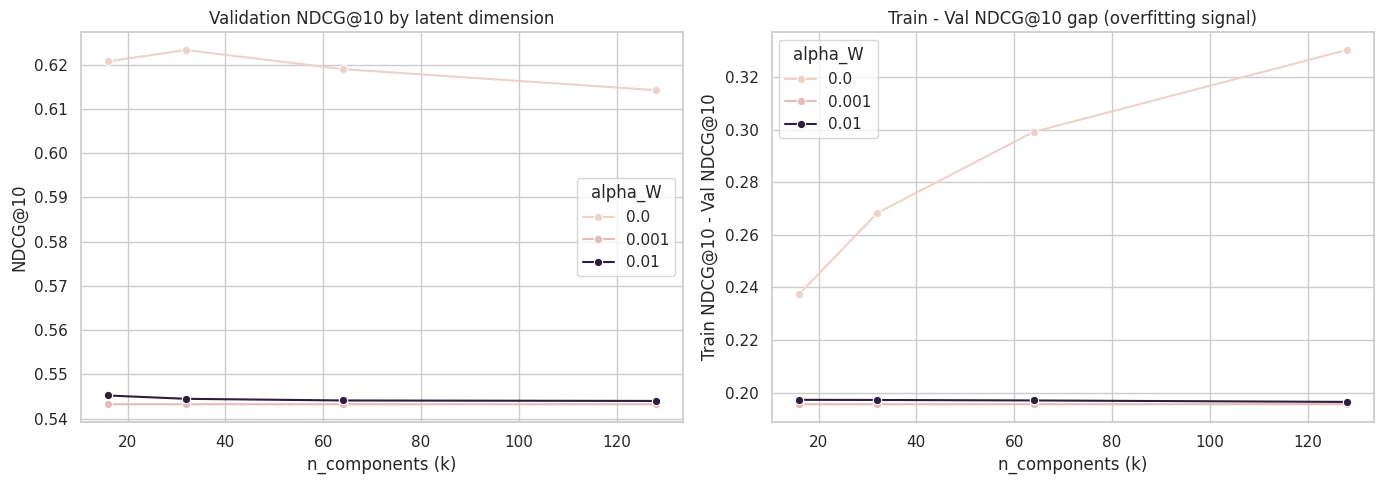

In [12]:
sweep_k10 = sweep_df[sweep_df["k_eval"] == 10].copy()
sweep_k10["train_val_gap_ndcg"] = sweep_k10["train_ndcg"] - sweep_k10["val_ndcg"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=sweep_k10, x="k_components", y="val_ndcg",
    hue="alpha_W", marker="o", ax=axes[0]
)
axes[0].set_title("Validation NDCG@10 by latent dimension")
axes[0].set_xlabel("n_components (k)")
axes[0].set_ylabel("NDCG@10")

sns.lineplot(
    data=sweep_k10, x="k_components", y="train_val_gap_ndcg",
    hue="alpha_W", marker="o", ax=axes[1]
)
axes[1].set_title("Train - Val NDCG@10 gap (overfitting signal)")
axes[1].set_xlabel("n_components (k)")
axes[1].set_ylabel("Train NDCG@10 - Val NDCG@10")

plt.tight_layout()
plt.show()

## 6. Final Model Selection

Pick the configuration with the highest **validation NDCG@10**. NDCG is the most appropriate ranking metric here because it penalizes putting relevant items lower in the list — closer to how a real recommender UI is consumed.

In [13]:
best_row = sweep_k10.sort_values("val_ndcg", ascending=False).iloc[0]
best_k = int(best_row["k_components"])
best_alpha = float(best_row["alpha_W"])

print(f"Best config: k={best_k}, alpha_W={best_alpha}")
print(f"Validation NDCG@10 = {best_row['val_ndcg']:.4f}")
print(f"Train  NDCG@10 = {best_row['train_ndcg']:.4f}")
print(f"Train-Val gap = {best_row['train_ndcg'] - best_row['val_ndcg']:.4f}")

W_best, H_best = factor_cache[(best_k, best_alpha)]

with open(os.path.join(MODEL_DIR, "nmf_W.npy"), "wb") as f:
    np.save(f, W_best)
with open(os.path.join(MODEL_DIR, "nmf_H.npy"), "wb") as f:
    np.save(f, H_best)
print(f"\nSaved best NMF factors to {MODEL_DIR}")

Best config: k=32, alpha_W=0.0
Validation NDCG@10 = 0.6233
Train  NDCG@10 = 0.8916
Train-Val gap = 0.2683

Saved best NMF factors to /content/drive/MyDrive/PixelRec50K/models


## 7. Final Test Evaluation

In [14]:
final_train_summary, _ = evaluate_nmf_on_samples(W_best, H_best, train_samples)
final_val_summary, _ = evaluate_nmf_on_samples(W_best, H_best, val_samples)
final_test_summary, _ = evaluate_nmf_on_samples(W_best, H_best, test_samples)

print("=== Final NMF Train ==="); display(final_train_summary)
print("=== Final NMF Validation ==="); display(final_val_summary)
print("=== Final NMF Test ==="); display(final_test_summary)

=== Final NMF Train ===


,k,precision,recall,ndcg
0,5,0.876052,0.428412,0.900004
1,10,0.765742,0.710396,0.891647
2,20,0.547535,0.910154,0.928702


=== Final NMF Validation ===


,k,precision,recall,ndcg
0,5,0.217788,0.756411,0.560150
1,10,0.143801,0.916903,0.623317
2,20,0.083657,0.982470,0.647994


=== Final NMF Test ===


,k,precision,recall,ndcg
0,5,0.188476,0.531208,0.392848
1,10,0.149824,0.791577,0.495643
2,20,0.099391,0.958639,0.555467


## 8. Top-N Example Recommendations

For qualitative inspection, generate top-10 recommendations for a few sample users. Items already seen in training are masked out so the model only suggests new content.

In [15]:
train_seen_by_user = (
    train_df
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

def recommend_top_n(user_idx, W, H, n=10):
    scores = W[user_idx] @ H  # shape (num_items,)
    seen = train_seen_by_user.get(user_idx, set())
    if seen:
        scores = scores.copy()
        scores[list(seen)] = -np.inf
    top_items = np.argsort(-scores)[:n]
    return top_items.tolist(), scores[top_items].tolist()

sample_users = test_df["user_idx"].drop_duplicates().sample(5, random_state=42).tolist()

example_rows = []
for user_idx in sample_users:
    items, scores = recommend_top_n(user_idx, W_best, H_best, n=10)
    for rank, (item_idx, score) in enumerate(zip(items, scores), start=1):
        example_rows.append({
            "user_idx": user_idx,
            "rank": rank,
            "recommended_item_idx": int(item_idx),
            "nmf_score": float(score)
        })

example_df = pd.DataFrame(example_rows)

# Join with item metadata for readability
item_info = pd.read_csv(os.path.join(DATASET_DIR, "pixel50k_item_info.csv"))
with open(os.path.join(PROCESSED_DIR, "item_encoder.pkl"), "rb") as f:
    item_encoder = pickle.load(f)

item_mapping = pd.DataFrame({
    "item_id": item_encoder.classes_,
    "item_idx": np.arange(len(item_encoder.classes_))
})

example_with_meta = (
    example_df
    .merge(item_mapping, left_on="recommended_item_idx", right_on="item_idx", how="left")
    .merge(item_info, on="item_id", how="left")
)

display(example_with_meta[["user_idx", "rank", "recommended_item_idx", "item_id", "nmf_score", "title", "tag"]].head(20))

example_with_meta.to_csv(
    os.path.join(RESULT_DIR, "nmf_example_recommendations.csv"),
    index=False
)

,user_idx,rank,recommended_item_idx,item_id,nmf_score,title,tag
0,8194,1,17315,i19025,0.012607,The muscle meat Yunlong!,Comedy
1,8194,2,18488,i196315,0.010559,Cat world confusing behavior: there is no way ...,Cats
2,8194,3,18938,i198660,0.010337,Only later did I realize that this passage fro...,Film and Television Editing
3,8194,4,3356,i117226,0.010324,I feel sorry for Niseenbashi's brother.,Comedy
4,8194,5,17925,i193345,0.009886,"Cat learns to speak Russian super standard, al...",Cats
5,8194,6,5498,i127894,0.009743,Mom: Doesn't Art Deserve Respect - Liu Huaqian...,Comedy
6,8194,7,162,i100796,0.009722,Shen Teng \ Jia Ling forced to operate!,Comedy
7,8194,8,17651,i192090,0.008856,"Is it a crime to engage in pornography? ""The H...","Social Sciences, Law, and Psychology"
8,8194,9,32330,i33445,0.008757,Pull your pants down in a second. ...... There...,Daily Life
9,8194,10,5560,i12825,0.008693,Which should I choose between a ton of dollar ...,Science and Popular Science


## 9. Interpret Latent Factors (qualitative learning)

Each row of `H` is a latent factor over items. The items with the largest weight in a factor represent the soft cluster that factor captures. This is the interpretability advantage of NMF over signed SVD.

In [16]:
def top_items_in_factor(factor_idx, top_n=10):
    weights = H_best[factor_idx]
    top_item_indices = np.argsort(-weights)[:top_n]
    rows = []
    for rank, item_idx in enumerate(top_item_indices, start=1):
        item_id = item_encoder.classes_[item_idx]
        meta = item_info[item_info["item_id"] == item_id]
        title = meta["title"].values[0] if len(meta) else ""
        tag = meta["tag"].values[0] if len(meta) else ""
        rows.append({
            "factor": factor_idx,
            "rank": rank,
            "item_idx": int(item_idx),
            "weight": float(weights[item_idx]),
            "title": title,
            "tag": tag
        })
    return pd.DataFrame(rows)

# Inspect a handful of factors to look for thematic clusters
for f in [0, 1, 5, 10]:
    print(f"\n=== Latent Factor {f} — top 10 items ===")
    display(top_items_in_factor(f, top_n=10))


=== Latent Factor 0 — top 10 items ===


,factor,rank,item_idx,weight,title,tag
0,0,1,28335,1.719105,"After the tragedy in Chengdu, I see the shadow...",Global
1,0,2,12551,1.490413,Russia banned from replacing national anthem w...,Global
2,0,3,29139,1.442927,Syrian man's family gets Chinese green cards: ...,Hot Topics
3,0,4,33385,1.416673,Nuclear wastewater into the sea! China's white...,Film and Television Editing
4,0,5,14789,1.381663,"Asians wearing ""I'm not Chinese"" clothes to pr...","Social Sciences, Law, and Psychology"
5,0,6,18337,1.333671,The Japanese V is a scene of overturning: the ...,"Social Sciences, Law, and Psychology"
6,0,7,6251,1.284941,"Woman: ""He's a Moor you have no right to take ...",Daily Life
7,0,8,13935,1.229872,"Chengdu, a medical student to see blood must b...",Hot Topics
8,0,9,15739,1.224200,The Japanese and Korean males have been castra...,Humanities and History
9,0,10,11704,1.201121,The first time I saw a video of a woman on a b...,Daily Life



=== Latent Factor 1 — top 10 items ===


,factor,rank,item_idx,weight,title,tag
0,1,1,30776,1.244603,[Zhou Shen / Hacken Lee] Sudden Love,Live Music
1,1,2,18862,1.223599,"Zhou Shen Please Believe in a Dream"" & ""This I...",Live Music
2,1,3,4471,1.158538,The current status of U.P.,Meme Creation
3,1,4,42089,1.034827,"Zhou Shen's multi-language rendition of ""A Tho...",Variety Shows
4,1,5,32256,1.034097,[Year of the Ox Spring Festival Gala] Expectat...,Fan Creation
5,1,6,8150,0.978696,[Creation Camp] Zhou Shen debuts on stage by r...,Variety Shows
6,1,7,26006,0.975371,Zhou Shen/Kabu] A Bloody Love Story LIVE [4-Ca...,Music Mix
7,1,8,35602,0.951861,"Love Shift"" Cantonese Version (High Quality So...",Live Music
8,1,9,47118,0.940693,[Ring of Youth] Zhou Shen Chen Zhuo Xuan sings...,Variety Shows
9,1,10,45889,0.914921,"Zhou Shen I, Jianghu! [A Dream of Jianghu 3rd ...",Original Music



=== Latent Factor 5 — top 10 items ===


,factor,rank,item_idx,weight,title,tag
0,5,1,13981,1.409834,The best apology king ！！！！！！!,Original Music
1,5,2,34113,1.397404,[Ryoji Bio-identification] Internet hot bio-id...,Science and Popular Science
2,5,3,45795,1.286807,[Old Tomato] What bad intentions can a little ...,Single-player Games
3,5,4,41135,1.263675,Commemorating the end of the Tomorrow's Ark x ...,Mobile Games
4,5,5,8317,1.190958,Rare video of keyboard warrior spraying people...,Meme Creation
5,5,6,16093,1.157408,East Wind Break,Meme Creation
6,5,7,6674,1.154788,This onion is taller than me! Eating it actual...,Food Reviews
7,5,8,36621,1.129734,Rating! I'm sure there's a madness with this o...,Miscellaneous
8,5,9,10394,1.118899,"This hand, I'm sure to win!",Mobile Games
9,5,10,29869,1.107755,The best game of the year to help people to ha...,Single-player Games



=== Latent Factor 10 — top 10 items ===


,factor,rank,item_idx,weight,title,tag
0,10,1,33444,0.547021,"Tencent's ""King's Honor"" is in court: the game...",Society
1,10,2,32954,0.491453,[Ya a certain burst of time] Da Qiao white cra...,Esports
2,10,3,8397,0.458637,[Yazhou Breaking Time] The warm and gentle Xis...,Esports
3,10,4,13709,0.448592,The new skin of Yao Nature's Spirit is coming ...,Esports
4,10,5,1156,0.440120,[Yaya Somewhere Breaking News Time] Imperial S...,Esports
5,10,6,32545,0.417077,[Ya a certain burst of time] Wang Zhaojun begg...,Esports
6,10,7,41457,0.415331,Super burning stomping! Showing homemade Chine...,Humanities and History
7,10,8,22477,0.400614,"Abuse of market dominance behavior, Alibaba Gr...",Miscellaneous
8,10,9,7120,0.395229,How the Japanese view the war of aggression ag...,Film and Television Editing
9,10,10,24975,0.393271,[Ya a certain burst of time] S season war orde...,Esports


## 10. Comparison Against the Popularity Baseline

In [17]:
def format_result(summary_df, model_name, features, split):
    out = summary_df.copy()
    out["model"] = model_name
    out["features"] = features
    out["split"] = split
    return out[["model", "features", "split", "k", "precision", "recall", "ndcg"]]

nmf_results = pd.concat([
    format_result(final_train_summary, "NMF (Matrix Factorization)", "User-item interactions only", "train"),
    format_result(final_val_summary, "NMF (Matrix Factorization)", "User-item interactions only", "validation"),
    format_result(final_test_summary, "NMF (Matrix Factorization)", "User-item interactions only", "test"),
], ignore_index=True)

nmf_results.to_csv(os.path.join(RESULT_DIR, "nmf_results.csv"), index=False)
sweep_df.to_csv(os.path.join(RESULT_DIR, "nmf_hyperparameter_sweep.csv"), index=False)

display(nmf_results)
print("Saved nmf_results.csv and nmf_hyperparameter_sweep.csv to", RESULT_DIR)

,model,features,split,k,precision,recall,ndcg
0,NMF (Matrix Factorization),User-item interactions only,train,5,0.876052,0.428412,0.900004
1,NMF (Matrix Factorization),User-item interactions only,train,10,0.765742,0.710396,0.891647
2,NMF (Matrix Factorization),User-item interactions only,train,20,0.547535,0.910154,0.928702
3,NMF (Matrix Factorization),User-item interactions only,validation,5,0.217788,0.756411,0.560150
4,NMF (Matrix Factorization),User-item interactions only,validation,10,0.143801,0.916903,0.623317
5,NMF (Matrix Factorization),User-item interactions only,validation,20,0.083657,0.982470,0.647994
6,NMF (Matrix Factorization),User-item interactions only,test,5,0.188476,0.531208,0.392848
7,NMF (Matrix Factorization),User-item interactions only,test,10,0.149824,0.791577,0.495643
8,NMF (Matrix Factorization),User-item interactions only,test,20,0.099391,0.958639,0.555467


Saved nmf_results.csv and nmf_hyperparameter_sweep.csv to /content/drive/MyDrive/PixelRec50K/results


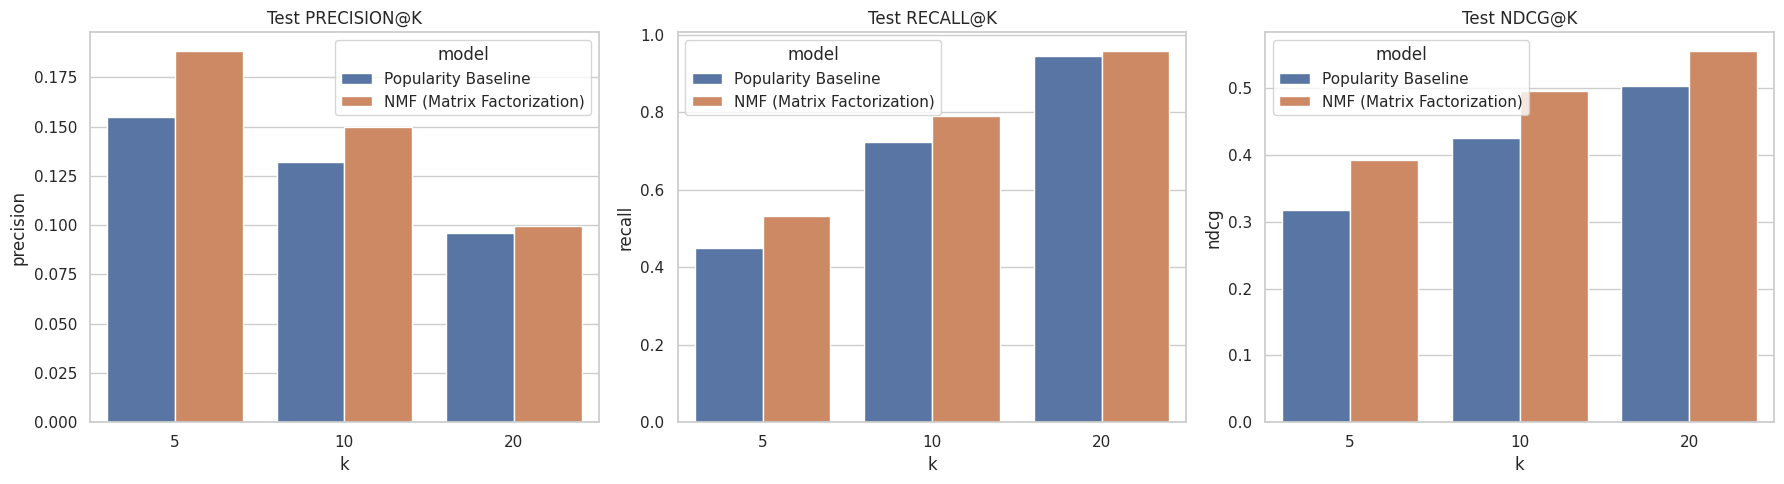


NMF lift over popularity baseline @K=10:


,metric,popularity,nmf,abs_lift,rel_lift_pct
0,precision,0.131894,0.149824,0.017930,13.594208
1,recall,0.723811,0.791577,0.067767,9.362490
2,ndcg,0.425213,0.495643,0.070430,16.563404


In [18]:
baseline_path = os.path.join(RESULT_DIR, "popularity_baseline_results.csv")

if os.path.exists(baseline_path):
    baseline_results = pd.read_csv(baseline_path)
    comparison = pd.concat([baseline_results, nmf_results], ignore_index=True)
    test_comp = comparison[comparison["split"] == "test"].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, ["precision", "recall", "ndcg"]):
        sns.barplot(data=test_comp, x="k", y=metric, hue="model", ax=ax)
        ax.set_title(f"Test {metric.upper()}@K")
    plt.tight_layout()
    plt.show()

    # Numeric improvement table at K=10
    pop = test_comp[(test_comp["model"].str.contains("Popularity")) & (test_comp["k"] == 10)].iloc[0]
    nmf = test_comp[(test_comp["model"].str.contains("NMF")) & (test_comp["k"] == 10)].iloc[0]

    improvement = pd.DataFrame({
        "metric": ["precision", "recall", "ndcg"],
        "popularity": [pop["precision"], pop["recall"], pop["ndcg"]],
        "nmf": [nmf["precision"], nmf["recall"], nmf["ndcg"]]
    })
    improvement["abs_lift"] = improvement["nmf"] - improvement["popularity"]
    improvement["rel_lift_pct"] = improvement["abs_lift"] / improvement["popularity"] * 100
    print("\nNMF lift over popularity baseline @K=10:")
    display(improvement)
else:
    print("popularity_baseline_results.csv not found — skipping comparison.")

## 11. Results, Learnings, and Future Work

**Results.** The final NMF model (k = 32, alpha_W = 0.0) improves over the popularity baseline on every ranking metric on the test set: Precision@10 rises from 0.132 to 0.150 (+13.6%), Recall@10 from 0.724 to 0.792 (+9.4%), and NDCG@10 from 0.425 to 0.496 (+16.6%). This confirms that the latent factor representation captures real personalization signal beyond global item popularity.

**On hyperparameter behavior — a finding worth noting.** The validation sweep shows two non-obvious results:

1. **The best latent dimension is k=32, not larger.** Validation NDCG@10 is 0.6233 at k=32, 0.6208 at k=16, 0.6190 at k=64, and 0.6143 at k=128. Capacity beyond ~32 stops helping and very slightly hurts validation performance — consistent with what we expect on a 99.97% sparse matrix where larger factor spaces start to memorize noise rather than learn structure.

2. **L2 regularization (alpha_W > 0) does not help here — it hurts.** Every configuration with alpha_W ∈ {0.001, 0.01} collapses validation NDCG@10 to ~0.544, regardless of k. This is a clean negative result: on this implicit-feedback matrix, sklearn's L2 penalty on `W` and `H` pulls the factors too aggressively toward zero, and because the model is already optimizing a reconstruction loss (not a ranking loss), the regularized factors lose the personalization signal faster than they reduce overfitting. The train-val gap at our chosen config is still substantial (Train NDCG@10 = 0.892 vs Val NDCG@10 = 0.623), and the right fix is not more L2 — it is a different loss function. This is exactly the gap that LightFM closes with WARP loss in Option 4.

**Methodological learnings.**
- For implicit feedback, NMF on the binary interaction matrix is a respectable, very fast baseline once k is chosen carefully: it is parameter-light, fully deterministic with NNDSVD init, and gives interpretable parts-based factors. The latent factor inspection in section 9 shows several factors clustering thematically by tag, which is hard to achieve with signed SVD.
- Candidate-based evaluation (positives + sampled negatives) lines up cleanly with how the popularity baseline and LightFM were evaluated, so all three models can be compared on the same numbers.
- A pure collaborative filtering approach has a clear ceiling on this dataset because 42.9% of raw items are below the 5-core threshold and were filtered out. After filtering, the model has no way to score genuinely cold items at all — this is the exact gap that Option 4 (LightFM with metadata features) and Option 5 (Factorization Machine / DeepFM) are designed to close.
- Comparing NMF (NDCG@10 = 0.496) against LightFM Interaction-Only (NDCG@10 ≈ 0.523) on the same data isolates the effect of the loss function alone — both are interaction-only latent factor models, but WARP ranking loss outperforms Frobenius reconstruction loss. Comparing NMF against LightFM Hybrid (NDCG@10 ≈ 0.616) then isolates the additional contribution of item metadata.

**Future work.**
- Replace squared-error NMF with implicit-feedback ALS (Hu, Koren, Volinsky 2008), which up-weights observed interactions with a confidence term and typically gives a meaningful lift on implicit data.
- Swap Frobenius loss for BPR or WARP loss so the model optimizes ranking directly rather than reconstruction. The validation sweep here suggests this is where the largest remaining gain lies.
- Add a popularity prior to the NMF score so the model degrades gracefully toward the popularity baseline for low-activity users.
- Combine NMF user factors with content-based item embeddings (cover image CLIP features + title embeddings) for cold-start items — a natural extension toward the planned multimodal model that overlaps with Option 5.